# Housing Price Regression with PCA and Feature Selection

## Overview

This project explores dimensionality reduction and feature selection techniques in machine learning using the House Prices dataset. Linear regression models were developed and evaluated before and after applying Principal Component Analysis (PCA) and variance threshold feature selection methods.

The project compares how preprocessing and feature engineering techniques influence regression model performance, interpretability, and dimensionality.

---

## Techniques Used

- Linear Regression
- PCA (90% variance retention)
- Variance Threshold Feature Selection
- Dummy Variable Encoding
- Missing Value Imputation
- MinMax Scaling
- Train/Test Split
- R² and RMSE Evaluation

---

## Dataset

The House Prices dataset was used to predict home sale prices based on multiple housing characteristics and engineered numerical features.

---

## Objective

The goal of this project was to evaluate how dimensionality reduction and feature selection impact machine learning model performance while reducing dataset complexity.

## Part 1: PCA and Variance Threshold in Linear Regression

### Load Training Dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


The dataset was successfully loaded and inspected to confirm structure and data types.

In [2]:
# Drop the Id column
df = df.drop(columns=["Id"])

# Calculate percentage of missing values per column
missing_percent = df.isnull().mean()

# Identify columns with more than 40% missing values
high_missing = missing_percent[missing_percent > 0.40]

# Drop those columns
df = df.drop(columns=high_missing.index)

# Verify results
print("New shape:", df.shape)
print("Remaining missing values:\n", df.isnull().sum().sort_values(ascending=False).head())

New shape: (1460, 74)
Remaining missing values:
 LotFrontage    259
GarageQual      81
GarageCond      81
GarageType      81
GarageYrBlt     81
dtype: int64


Columns with more than 40% missing values were removed to improve data quality and reduce noise in the model. These features contained insufficient information for reliable analysis and could negatively impact model performance. After removal, the dataset was reduced from 81 to 74 features, retaining the majority of useful variables while eliminating sparsely populated ones.

In [3]:
# Identify column types
num_cols = df.select_dtypes(include=["number"]).columns
cat_cols = df.select_dtypes(include=["object", "string"]).columns

# Impute missing values
# Numerical → median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical → mode
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

# Make a copy to look at how the dummy variables factored in
df_original = df.copy()

# Convert categorical variables to dummy variables
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Final verification
print("Final shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())
print("Any nulls left?", df.isnull().values.any())

Final shape: (1460, 230)
Remaining missing values: 0
Any nulls left? False


Missing values in numerical features were imputed using the median to minimize the influence of extreme values. Categorical variables were imputed using the mode, preserving the most frequently occurring category within each feature. Following imputation, categorical variables were transformed into dummy variables using one-hot encoding with the first category dropped to prevent multicollinearity. This preprocessing step resulted in a fully numeric dataset with no missing values, suitable for machine learning modeling. Converting categorical variables into dummy variables significantly increased the number of features in the dataset. This is expected, as each categorical variable is expanded into multiple binary indicators representing each category. While this increases dimensionality, it allows machine learning models to interpret categorical data numerically.

In [4]:
# Recreate dummy column counts
dummy_cols = df.columns

dummy_counts = {}

for col in cat_cols:
    prefix = col + "_"
    count = sum(dummy_cols.str.startswith(prefix))
    dummy_counts[col] = count

dummy_summary = pd.DataFrame.from_dict(
    dummy_counts, orient='index', columns=['num_dummy_columns']
)

### Dummy Variable Expansion Analysis

The table below shows how categorical variables expanded after one-hot encoding. 
Features such as Neighborhood and Exterior types produced the largest number 
of dummy variables due to their high number of unique categories. This 
contributed significantly to the increase in dimensionality from the original dataset.

In [5]:
# Original category counts
original_counts = df_original[cat_cols].nunique()

comparison = pd.DataFrame({
    "original_categories": original_counts,
    "dummy_columns": dummy_summary["num_dummy_columns"]
})

comparison.sort_values(by="dummy_columns", ascending=False)

,original_categories,dummy_columns
Neighborhood,25,24
Exterior2nd,16,15
Exterior1st,15,14
Condition1,9,8
SaleType,9,8
Condition2,8,7
HouseStyle,8,7
RoofMatl,8,7
Functional,7,6
BsmtFinType2,6,5


## Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split

# Separate features and target variable
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Verify shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1168, 229)
X_test shape: (292, 229)
y_train shape: (1168,)
y_test shape: (292,)


The `SalePrice` column was used as the target variable, while all remaining columns were used as predictor features. The data was split into training and test sets using an 80/20 split so the model could be trained on one portion of the data and evaluated on unseen data.

## Baseline Linear Regression Model

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Create and train the linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred = lr_model.predict(X_test)

# Evaluate model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline Linear Regression R2:", r2)
print("Baseline Linear Regression RMSE:", rmse)

Baseline Linear Regression R2: 0.6478367401193776
Baseline Linear Regression RMSE: 51973.13807603682


The baseline linear regression model achieved an R² value of approximately 0.65, indicating that the model explains about 65% of the variance in housing prices. The RMSE of approximately 51,973 suggests that, on average, the model's predictions deviate from the actual sale prices by about $52,000. This baseline model provides a reference point for evaluating the impact of feature reduction techniques.

### Train/Test Split and Baseline Linear Regression
Baseline model used to predict housing sale price using an 80/20 train-test split and evaluated with R² and RMSE.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Separate features and target variable
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# Split the data into training and test sets
# test_size=0.2 means 20% test data and 80% training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create and train the baseline linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict SalePrice values for the test set
y_pred = lr_model.predict(X_test)

# Evaluate the baseline model
baseline_r2 = r2_score(y_test, y_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print(f"Baseline Linear Regression R²: {baseline_r2:.3f}")
print(f"Baseline Linear Regression RMSE: {baseline_rmse:.2f}")

X_train shape: (1168, 229)
X_test shape: (292, 229)
Baseline Linear Regression R²: 0.648
Baseline Linear Regression RMSE: 51973.14


The dataset was split into training and test sets using an 80/20 split. 
The `SalePrice` column was used as the target variable, while all remaining columns were used as predictors. 
A baseline linear regression model was fit on the training data and evaluated on the test data using R² and RMSE. 
This baseline model will be compared against the PCA-transformed model and the high-variance feature model in later sections.

## PCA Transformation (90% Variance Retained)

In [9]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Fit PCA on TRAIN ONLY, retain 90% variance
pca = PCA(n_components=0.90, random_state=42)
X_train_pca = pca.fit_transform(X_train)

# Transform TEST using the same PCA (DO NOT FIT)
X_test_pca = pca.transform(X_test)

# How many features after PCA?
print("Number of PCA components:", X_train_pca.shape[1])

# Train linear regression on PCA features
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)

# Predict and evaluate
y_pred_pca = lr_pca.predict(X_test_pca)

pca_r2 = r2_score(y_test, y_pred_pca)
pca_rmse = np.sqrt(mean_squared_error(y_test, y_pred_pca))

print("PCA Linear Regression R2:", pca_r2)
print("PCA Linear Regression RMSE:", pca_rmse)

Number of PCA components: 1
PCA Linear Regression R2: 0.06348978213632539
PCA Linear Regression RMSE: 84754.58021474867


PCA was applied to reduce dimensionality while retaining 90% of the variance. The number of resulting principal components is shown above. The PCA-transformed features were then used to train and evaluate a linear regression model.

## Min-Max Scaling and Variance Threshold (> 0.1)

In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold

# Scale TRAIN ONLY
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaling to TEST (DO NOT FIT)
X_test_scaled = scaler.transform(X_test)

# Variance threshold on TRAIN ONLY
selector = VarianceThreshold(threshold=0.1)
X_train_highvar = selector.fit_transform(X_train_scaled)

# Apply same selection to TEST (DO NOT FIT)
X_test_highvar = selector.transform(X_test_scaled)

# How many features remain?
print("Number of high-variance features:", X_train_highvar.shape[1])

# Train linear regression on selected features
lr_var = LinearRegression()
lr_var.fit(X_train_highvar, y_train)

# Predict and evaluate
y_pred_var = lr_var.predict(X_test_highvar)

var_r2 = r2_score(y_test, y_pred_var)
var_rmse = np.sqrt(mean_squared_error(y_test, y_pred_var))

print("High-Variance Linear Regression R2:", var_r2)
print("High-Variance Linear Regression RMSE:", var_rmse)

Number of high-variance features: 40
High-Variance Linear Regression R2: 0.6481229411342259
High-Variance Linear Regression RMSE: 51952.0146512729


Min-Max scaling was applied to normalize feature values between 0 and 1. A variance threshold of 0.1 was then used to remove low-variance features. The remaining features were used to train and evaluate a linear regression model.

## Model Comparison

In [11]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Baseline", "PCA (90% variance)", "High Variance (>0.1)"],
    "R2": [baseline_r2, pca_r2, var_r2],
    "RMSE": [baseline_rmse, pca_rmse, var_rmse]
})

results

,Model,R2,RMSE
0,Baseline,0.647837,51973.138076
1,PCA (90% variance),0.063490,84754.580215
2,High Variance (>0.1),0.648123,51952.014651


### Interpretation of Model Comparison

The comparison shows that the baseline and high-variance models performed similarly, with the high-variance model achieving slightly better R² and lower RMSE. In contrast, the PCA model performed significantly worse, with a much lower R² and higher RMSE. This suggests that while PCA reduced dimensionality, it also removed important predictive information, whereas variance-based feature selection helped improve model efficiency without sacrificing performance.

### Summary of Findings

The baseline linear regression model provided a reference for model performance using all available features. Applying PCA reduced the dimensionality of the dataset while retaining 90% of the variance; however, this resulted in a significant decrease in model performance. The PCA-transformed model produced a much lower R² value and a substantially higher RMSE, indicating that important predictive information was lost during dimensionality reduction.

The variance threshold method, applied after min-max scaling, slightly improved model performance compared to the baseline. By removing low-variance features, the model achieved a marginally higher R² and a lower RMSE, suggesting that eliminating less informative predictors can improve model efficiency without sacrificing accuracy.

Comparing the three approaches, the high-variance feature selection method produced the best overall performance, while PCA performed the worst. These results demonstrate that while dimensionality reduction techniques like PCA can simplify the dataset, they may not always preserve the most predictive features for regression tasks. In contrast, targeted feature selection based on variance can be a more effective approach for improving model performance.

## Part 2: Categorical Feature Selection
### Load Mushrooms Dataset

In [12]:
import pandas as pd

# Update path/filename if needed
df_mush = pd.read_csv("mushrooms.csv")

# Quick check
df_mush.head()
df_mush.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

The mushroom dataset was successfully loaded. All features are categorical, and the target variable indicates whether a mushroom is edible or poisonous.

## Define Features and Target

In [13]:
# Target variable
y = df_mush["class"]

# Features
X = df_mush.drop(columns=["class"])

The target variable (`class`) represents whether a mushroom is edible or poisonous, while all remaining columns are used as predictor features for the classification model.

## One-Hot Encoding

In [14]:
X = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X.shape)

Shape after encoding: (8124, 95)


All categorical features were converted into dummy variables using one-hot encoding to allow compatibility with machine learning models.

## Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

The dataset was split into training and test sets using an 80/20 split. Stratification was not applied because the target variable (SalePrice) is continuous, making this a regression task rather than a classification problem.

## Decision Tree Classifier

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Train model
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Predict
y_pred = tree.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)

Accuracy: 1.0
Confusion Matrix:
 [[843   0]
 [  0 782]]


The decision tree classifier achieved the accuracy shown above. The confusion matrix provides insight into how well the model distinguishes between edible and poisonous mushrooms.

## Decision Tree Visualization

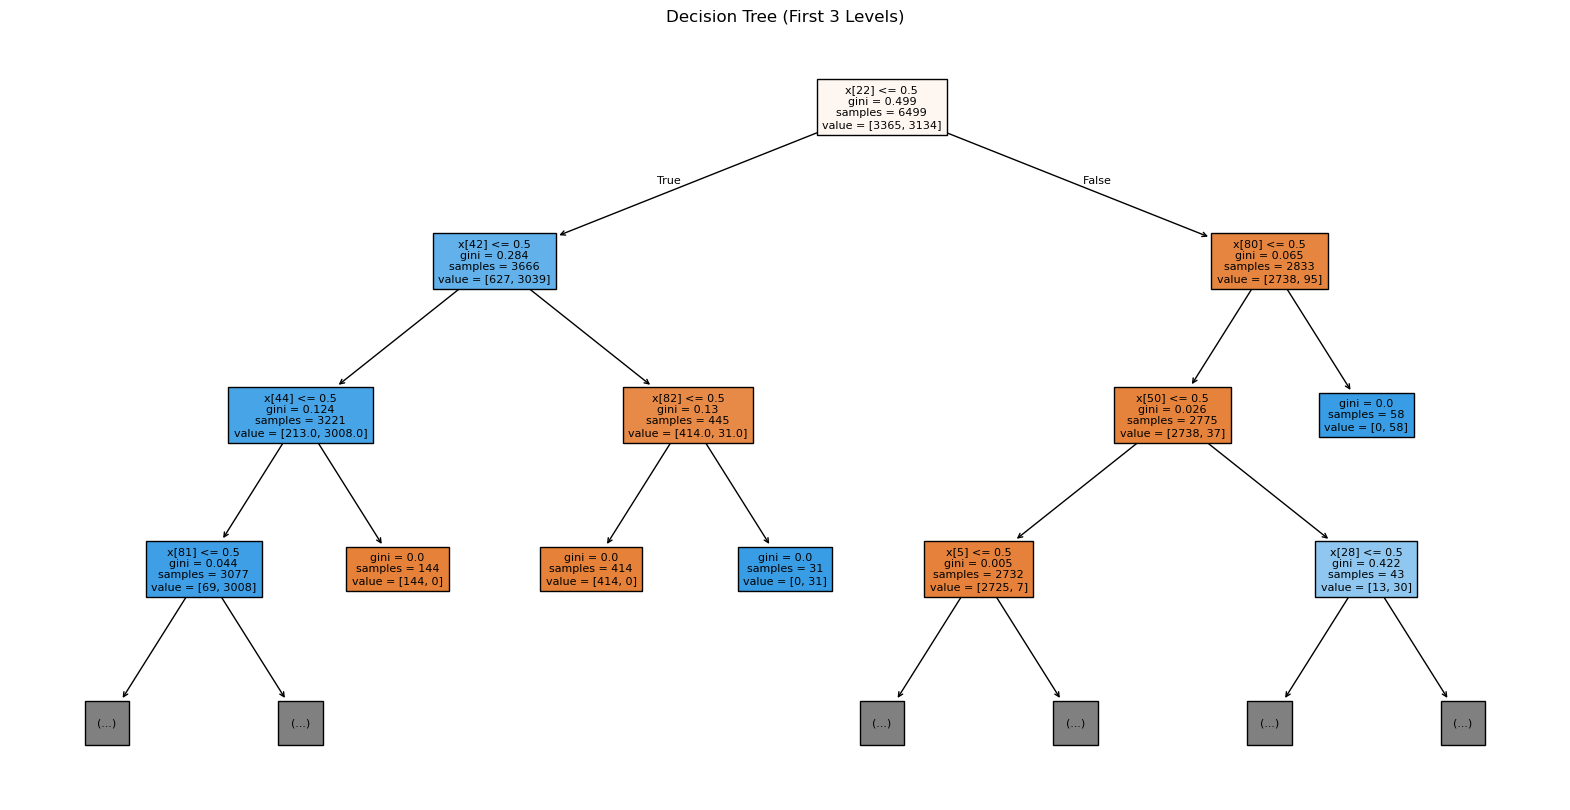

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(tree, filled=True, max_depth=3, fontsize=8)
plt.title("Decision Tree (First 3 Levels)")
plt.show()

### Decision Tree Interpretation

The decision tree visualization shows how the model splits the data based on different feature thresholds to classify mushrooms as edible or poisonous. Each node represents a decision rule, and the colors indicate the predicted class, with blue and orange corresponding to the two classes.

The tree quickly separates the data into relatively pure groups, as shown by low Gini impurity values in many nodes. This indicates that the model is highly effective at distinguishing between edible and poisonous mushrooms. The early splits suggest that a small number of features play a significant role in classification.

## Chi-Squared Feature Selection (Top 5 Features)

In [18]:
from sklearn.feature_selection import SelectKBest, chi2

# Select top 5 features
selector = SelectKBest(score_func=chi2, k=5)

X_train_chi2 = selector.fit_transform(X_train, y_train)
X_test_chi2 = selector.transform(X_test)

# Get selected feature names
selected_features = X.columns[selector.get_support()]

print("Top 5 features:")
print(selected_features)

Top 5 features:
Index(['odor_f', 'odor_n', 'gill-size_n', 'stalk-surface-above-ring_k',
       'stalk-surface-below-ring_k'],
      dtype='str')


The chi-squared (χ²) test was used to evaluate the relationship between each feature and the target variable (mushroom edibility). The five features with the strongest statistical association were selected, as they are the most informative for distinguishing between edible and poisonous mushrooms.

## Decision Tree with Selected Features

In [19]:
# Train model on reduced feature set
tree_chi2 = DecisionTreeClassifier(random_state=42)
tree_chi2.fit(X_train_chi2, y_train)

# Predict
y_pred_chi2 = tree_chi2.predict(X_test_chi2)

# Evaluate
acc_chi2 = accuracy_score(y_test, y_pred_chi2)
cm_chi2 = confusion_matrix(y_test, y_pred_chi2)

print("Accuracy (Top 5 Features):", acc_chi2)
print("Confusion Matrix:\n", cm_chi2)

Accuracy (Top 5 Features): 0.9735384615384616
Confusion Matrix:
 [[816  27]
 [ 16 766]]


### Interpretation of Reduced Model Performance

The decision tree model using only the top five selected features achieved an accuracy of approximately 97.4%, indicating strong predictive performance even with a significantly reduced feature set. The confusion matrix shows that the model correctly classified the majority of both edible and poisonous mushrooms, with relatively few misclassifications.

This demonstrates that a small number of highly informative features can effectively capture the key patterns in the data, allowing the model to maintain high accuracy while reducing complexity. 

## Model Comparison

In [20]:
results = pd.DataFrame({
    "Model": ["Full Feature Set", "Top 5 Features (Chi-Squared)"],
    "Accuracy": [acc, acc_chi2]
})

results

,Model,Accuracy
0,Full Feature Set,1.000000
1,Top 5 Features (Chi-Squared),0.973538


## Key Findings

In the regression portion of this project, Principal Component Analysis (PCA) successfully reduced dataset dimensionality while retaining 90% of the variance. However, reducing dimensionality through PCA also decreased model performance, suggesting that variance preservation alone does not guarantee predictive strength.

Variance threshold feature selection slightly improved regression performance by removing low-variance features that contributed more noise than meaningful predictive information. This demonstrated that targeted feature selection can sometimes outperform broader dimensionality reduction techniques.

In the classification portion of the project, a decision tree classifier achieved strong predictive accuracy on the mushroom dataset. Applying chi-squared feature selection identified a smaller subset of highly informative features while maintaining strong classification performance.

Overall, the project demonstrated that dimensionality reduction and feature selection methods must be evaluated carefully within the context of the modeling objective. Techniques that simplify datasets do not always improve predictive performance, but they can improve interpretability and reduce model complexity when applied appropriately.